In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp


In [38]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation_with_raw.h5ad')
CELLTYPES_TO_KEEP = [
    # --- Astrocytes ---
    "Telencephalon astrocytes",
    "Olfactory astrocytes",

    # --- Oligodendrocyte lineage ---
    "Mature oligodendrocytes",
    "Oligodendrocytes precursor cells",

    # --- Microglia ---
    "Microglia",
]  # e.g., ["Mature oligodendrocytes", "Microglia"]
adata = adata[adata.obs.cell_class.isin(CELLTYPES_TO_KEEP)]

In [63]:
# ==== Install (first time only) ====
# %pip install pandas numpy scipy anndata seaborn matplotlib pymc arviz tqdm

import numpy as np
import pandas as pd
import anndata as ad
from scipy.sparse import issparse
from tqdm import tqdm

# -----------------------------
# Configuration (edit these)
# -----------------------------
CELLTYPE_COL  = "cell_class"   # column in adata.obs
SAMPLE_COL    = "sample_id"
AGE_COL       = "age"
COND_COL      = "condition"    # (e.g., "control" vs "mtdsb")
LAYER_COUNTS  = "counts"       # if absent we'll use .X


# -----------------------------
# Utility: pseudobulk by groups
# -----------------------------
import numpy as np
import pandas as pd
import scipy.sparse as sp

# --- tell the code where the counts live ---
LAYER_COUNTS = "counts"   # change if your raw counts are in another layer
CELLTYPE_COL = "cell_class"   # or whatever column you’re using
SAMPLE_COL   = "sample_id"    # sample in .obs
AGE_COL      = "age"
COND_COL     = "condition"

def _as_csr(X):
    if sp.issparse(X):
        return X.tocsr()
    # dense -> csr
    return sp.csr_matrix(np.asarray(X), copy=False)

def pseudobulk_by_groups(adata, group_cols, layer=None, keep_celltypes=None):
    """
    Sum raw counts per (celltype, sample, age, condition).
    Returns:
      pb_counts : dense float32 array (n_groups x n_genes)
      groups_df : dataframe with group labels (n_groups x len(group_cols))
      var_names : pandas Index of gene names
    """
    # 0) pull matrix & obs
    if layer is None:
        X = _as_csr(adata.X)
    else:
        if layer not in adata.layers:
            raise ValueError(f"Layer '{layer}' not found in adata.layers")
        X = _as_csr(adata.layers[layer])

    obs = adata.obs.copy()

    # 1) optional filter of cell types
    if keep_celltypes is not None:
        obs = obs.loc[obs[CELLTYPE_COL].isin(keep_celltypes)]
        X   = X[obs.index, :]   # keep matrix aligned

    # 2) make sure group columns exist and are strings (avoid categorical gotchas)
    for c in group_cols:
        if c not in obs.columns:
            raise ValueError(f"Missing obs column: {c}")
    gdf = obs.loc[:, group_cols].astype(str).copy()

    # 3) build an integer code per group
    key = pd.MultiIndex.from_frame(gdf, names=group_cols)
    codes, uniques = pd.factorize(key, sort=True)

    # 4) aggregate counts by group using a sparse trick
    n_groups = len(uniques)
    n_genes  = X.shape[1]
    ones     = np.ones(X.shape[0], dtype=np.int64)
    row_idx  = codes  # which group each cell belongs to

    # make a sparse "group-by" matrix G (cells -> groups), then G @ X = group sums
    G = sp.csr_matrix((ones, (row_idx, np.arange(X.shape[0]))), shape=(n_groups, X.shape[0]))
    pb_sparse = G @ X
    pb_counts = np.asarray(pb_sparse.todense(), dtype=np.float32)

    # 5) unpack group labels
    groups_df = uniques.to_frame(index=False)  # columns=group_cols
    groups_df.columns = group_cols

    return pb_counts, groups_df.reset_index(drop=True), adata.var_names.copy()
# -----------------------------
# CPM + log1p normalization
# -----------------------------
def normalize_pseudobulk(pb_counts, axis=1, libsize_scale=1e6):
    """
    CPM + log1p with zero-safe division.
    axis=1 means library size per row (sample/group).
    """
    X = np.asarray(pb_counts, dtype=np.float32)
    if axis == 1:
        lib = X.sum(1, keepdims=True)  # group sums
    else:
        lib = X.sum(0, keepdims=True)

    # avoid /0 -> NaN
    lib = np.where(lib == 0.0, 1.0, lib)
    X_cpm = (X / lib) * libsize_scale
    return np.log1p(X_cpm).astype(np.float32)

# -----------------------------
# Long-format builder
# -----------------------------
def pseudobulk_to_long_with_celltype(pb_norm, groups_df, var_names,
                                     sample_col=SAMPLE_COL, age_col=AGE_COL,
                                     cond_col=COND_COL, celltype_col=CELLTYPE_COL,
                                     value_name="value"):
    """
    Returns tidy df: [sample, age, condition, cell_type, gene, value]
    """
    n_groups, n_genes = pb_norm.shape
    assert n_groups == len(groups_df), "shape mismatch"

    # build a dataframe carefully
    df = pd.DataFrame(pb_norm, columns=var_names)
    df.insert(0, sample_col, groups_df[sample_col].values)
    df.insert(1, age_col,    groups_df[age_col].values)
    df.insert(2, cond_col,   groups_df[cond_col].values)
    df.insert(3, celltype_col, groups_df[celltype_col].values)

    # wide -> long
    long = df.melt(
        id_vars=[sample_col, age_col, cond_col, celltype_col],
        var_name="gene", value_name=value_name
    )
    # ensure expected dtypes
    long[age_col] = long[age_col].astype(str)
    long[cond_col] = long[cond_col].astype(str)
    long[celltype_col] = long[celltype_col].astype(str)
    long[sample_col] = long[sample_col].astype(str)

    return long


In [64]:
# -----------------------------
# RUN pseudobulk
# -----------------------------
pb_counts, groups_df, var_names = pseudobulk_by_groups(
     adata, group_cols=(CELLTYPE_COL, SAMPLE_COL, AGE_COL, COND_COL),
     layer=LAYER_COUNTS if LAYER_COUNTS in adata.layers else None
 )
pb_norm = normalize_pseudobulk(pb_counts, axis=1)
df_long = pseudobulk_to_long_with_celltype(pb_norm, groups_df, var_names)

In [65]:
df_long

,sample_id,age,condition,cell_class,gene,value
0,RB4282,60,control,Mature oligodendrocytes,2610035D17Rik,4.598890
1,RB4350,60,control,Mature oligodendrocytes,2610035D17Rik,4.798055
2,RB4401,60,mtDSB,Mature oligodendrocytes,2610035D17Rik,4.939253
3,RB4403,60,mtDSB,Mature oligodendrocytes,2610035D17Rik,4.772352
4,RB4405,60,mtDSB,Mature oligodendrocytes,2610035D17Rik,5.025128
...,...,...,...,...,...,...
306055,RB4627,21,mtDSB,Telencephalon astrocytes,a,0.285294
306056,RB4630,21,mtDSB,Telencephalon astrocytes,a,0.255448
306057,RB4653,21,mtDSB,Telencephalon astrocytes,a,0.262754
306058,RB4658,21,control,Telencephalon astrocytes,a,0.847408


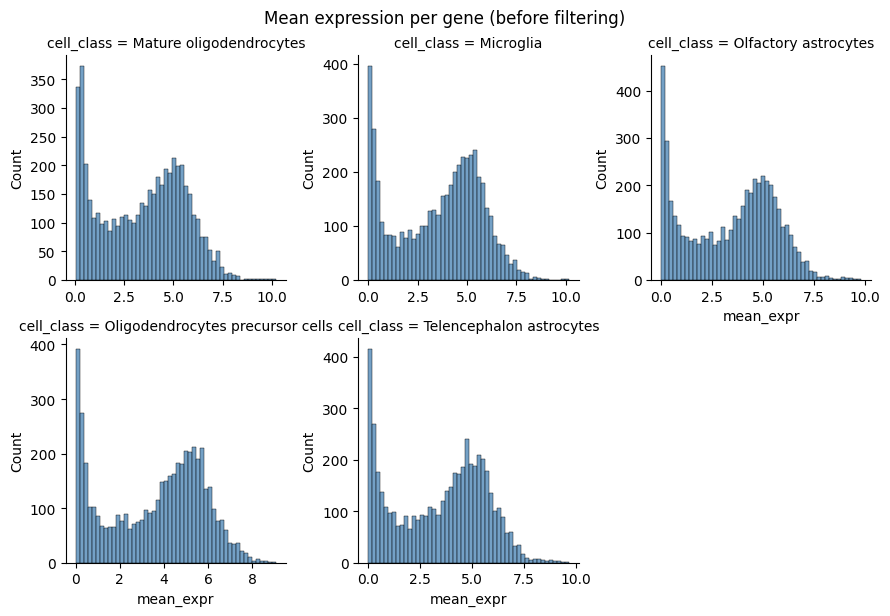

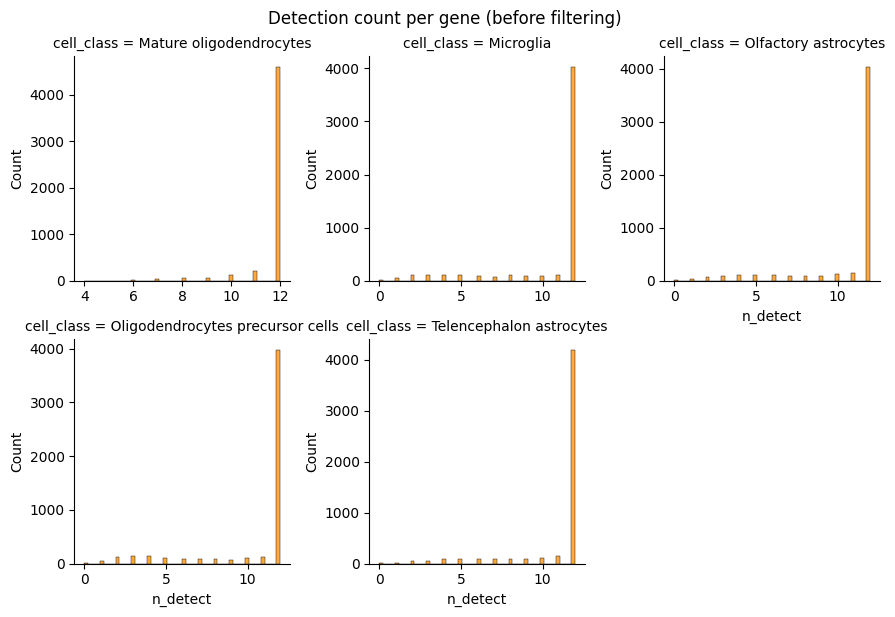

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# compute stats per gene and cell type
stats_all = (
    df_long
    .groupby(["cell_class", "gene"])
    .agg(
        mean_expr=("value", "mean"),
        n_detect=("value", lambda x: (x > 0).sum())
    )
    .reset_index()
)

# Plot distributions per cell type
g = sns.FacetGrid(stats_all, col="cell_class", col_wrap=3, sharex=False, sharey=False)
g.map(sns.histplot, "mean_expr", bins=50, color="steelblue")
g.fig.suptitle("Mean expression per gene (before filtering)", y=1.02)
plt.show()

g = sns.FacetGrid(stats_all, col="cell_class", col_wrap=3, sharex=False, sharey=False)
g.map(sns.histplot, "n_detect", bins=50, color="darkorange")
g.fig.suptitle("Detection count per gene (before filtering)", y=1.02)
plt.show()

In [95]:
# thresholds (edit to taste)
MIN_MEAN   = 3     # per (cell_type, gene) mean expression on log1p-CPM scale
MIN_DET    = 3       # gene must be detected (>0) in at least N samples within a cell type

def filter_low_genes(df_long, min_mean=MIN_MEAN, min_detect=MIN_DET):
    kept = []
    for ct, dfc in df_long.groupby("cell_class"):
        stats = (dfc
                 .groupby("gene")
                 .agg(mean_expr=("value","mean"),
                      n_detect=("value", lambda x: (x>0).sum()))
                 .reset_index())
        good = stats[(stats.mean_expr >= min_mean) & (stats.n_detect >= min_detect)].gene
        kept.append(dfc[dfc.gene.isin(good)])
    return pd.concat(kept, ignore_index=True)

df_filtered = filter_low_genes(df_long)
print("rows before:", len(df_long), "after:", len(df_filtered))

rows before: 306060 after: 186264


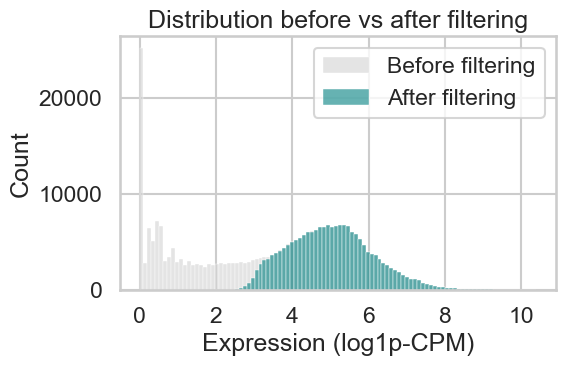

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compare all cell types pooled
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df_long["value"], bins=100, label="Before filtering", color="lightgray", alpha=0.6)
sns.histplot(df_filtered["value"], bins=100, label="After filtering", color="teal", alpha=0.6)
plt.legend()
plt.xlabel("Expression (log1p-CPM)")
plt.title("Distribution before vs after filtering")
plt.tight_layout()
plt.show()

In [97]:
import pymc as pm
import arviz as az

def fit_gene_pymc_ac(df_gene, *, advi=False, draws=1000, tune=1000, chains=4,
                     target_accept=0.9, seed=42):
    """
    value ~ age + condition + age:condition + (1|sample)
    df_gene is one (cell_type, gene).
    """
    df = df_gene.copy()
    ages    = sorted(df["age"].astype(str).unique())
    conds   = sorted(df["condition"].astype(str).unique())
    samples = sorted(df["sample_id"].astype(str).unique())

    A = len(ages); C = len(conds); S = len(samples)

    age_idx    = df["age"].astype(str).apply(ages.index).to_numpy()
    cond_idx   = df["condition"].astype(str).apply(conds.index).to_numpy()
    sample_idx = df["sample_id"].astype(str).apply(samples.index).to_numpy()
    y          = df["value"].to_numpy()

    with pm.Model() as m:
        sigma         = pm.HalfNormal("sigma", 0.7)
        sigma_sample  = pm.HalfNormal("sigma_sample", 0.5)
        sample_offset = pm.Normal("sample_offset", 0.0, sigma_sample, shape=S)

        beta_age         = pm.Normal("beta_age", 0.0, 0.5, shape=A)
        beta_cond        = pm.Normal("beta_cond", 0.0, 0.5, shape=C)
        beta_interaction = pm.Normal("beta_interaction", 0.0, 0.5, shape=(A, C))

        mu = (
            beta_age[age_idx]
          + beta_cond[cond_idx]
          + beta_interaction[age_idx, cond_idx]
          + sample_offset[sample_idx]
        )

        pm.Normal("obs", mu, sigma, observed=y)

        if advi:
            approx = pm.fit(20_000, random_seed=seed, progressbar=True)
            idata  = approx.sample(draws)
        else:
            idata = pm.sample(draws=draws, tune=tune, chains=chains,
                              target_accept=target_accept, random_seed=seed,
                              return_inferencedata=True, progressbar=True)

    meta = {"ages": ages, "conds": conds}
    return idata, meta

def _summarize_1d(samples):
    q = np.quantile(samples, [0.025, 0.975])
    return float(samples.mean()), float(q[0]), float(q[1])

def summarize_effects_ac(idata, meta):
    """
    Report:
      - mtDSB_at_age  = (mtDSB - control) at each age
      - age_interaction(old-young) = difference of those contrasts between oldest and youngest age
    """
    ages  = meta["ages"]
    conds = [c.lower() for c in meta["conds"]]

    # indices for control & mtDSB
    i_ctrl = conds.index("control") if "control" in conds else 0
    i_mt   = conds.index("mtdsb")   if "mtdsb"   in conds else (1 if len(conds)>1 else 0)

    beta_cond = idata.posterior["beta_cond"].values.reshape(-1, len(conds))
    beta_int  = idata.posterior["beta_interaction"].values.reshape(-1, len(ages), len(conds))

    rows = []

    # mtDSB effect at each age
    for a, age in enumerate(ages):
        diff = (beta_cond[:, i_mt] - beta_cond[:, i_ctrl]) + (beta_int[:, a, i_mt] - beta_int[:, a, i_ctrl])
        mean, lo, hi = _summarize_1d(diff)
        rows.append({
            "effect": "mtDSB_at_age", "age": age,
            "mean": mean, "hdi_2.5%": lo, "hdi_97.5%": hi,
            "term": f"beta[{age}] (mtDSB effect @ age)"
        })

    # age interaction: oldest – youngest
    if len(ages) >= 2:
        a_lo, a_hi = 0, len(ages)-1
        d_hi = (beta_cond[:, i_mt] - beta_cond[:, i_ctrl]) + (beta_int[:, a_hi, i_mt] - beta_int[:, a_hi, i_ctrl])
        d_lo = (beta_cond[:, i_mt] - beta_cond[:, i_ctrl]) + (beta_int[:, a_lo, i_mt] - beta_int[:, a_lo, i_ctrl])
        ai  = d_hi - d_lo
        mean, lo, hi = _summarize_1d(ai)
        rows.append({
            "effect": "age_interaction", "age": f"{ages[a_hi]}–{ages[a_lo]}",
            "mean": mean, "hdi_2.5%": lo, "hdi_97.5%": hi,
            "term": f"age_interaction({ages[a_hi]} - {ages[a_lo]})"
        })
    return pd.DataFrame(rows)

In [98]:
import pandas as pd
from collections import defaultdict
from pathlib import Path

# ---------------------------------------------------------------------
# 1) Load the shortlist and normalize its shape
# ---------------------------------------------------------------------
def shortlist_present(df_filtered, shortlists, celltype_col="cell_class"):
    present = {}
    for ct, genes in shortlists.items():
        have = set(df_filtered.loc[df_filtered[celltype_col] == ct, "gene"].unique())
        keep = [g for g in genes if g in have]
        if not keep:
            print(f"[warn] No shortlisted genes found in df for '{ct}' (skipping).")
        else:
            print(f"{ct}: using {len(keep)}/{len(genes)} shortlisted genes present in data")
        present[ct] = keep
    return present


def fit_many_genes(df_long, genes, celltypes,
                   *, celltype_col="cell_class",
                   advi=False, draws=1000, tune=1000, chains=4,
                   target_accept=0.9, seed=42):
    rows = []
    for ct in celltypes:
        df_ct = df_long[df_long[celltype_col] == ct]
        for g in genes:
            sub = df_ct[df_ct["gene"] == g]
            if sub.empty:
                continue
            idata, meta = fit_gene_pymc_ac(sub, advi=advi, draws=draws, tune=tune,
                                           chains=chains, target_accept=target_accept, seed=seed)
            eff = summarize_effects_ac(idata, meta)
            eff.insert(0, "gene", g)
            eff.insert(0, celltype_col, ct)   # keep the same column name
            rows.append(eff)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def run_shortlisted_fits(df_filtered, shortlist_csv, out_dir="./",
                         *, celltype_col="cell_class",
                         advi=False, draws=1000, tune=1000, chains=4,
                         target_accept=0.9, seed=42):
    from pathlib import Path
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)

    shortlists = load_shortlists(shortlist_csv)
    shortlists = shortlist_present(df_filtered, shortlists, celltype_col=celltype_col)

    all_summaries = []
    for ct, genes in shortlists.items():
        if not genes:
            continue
        print(f"\nFitting {ct} — {len(genes)} shortlisted genes")

        sct = fit_many_genes(df_filtered, genes, [ct],
                             celltype_col=celltype_col,
                             advi=advi, draws=draws, tune=tune, chains=chains,
                             target_accept=target_accept, seed=seed)
        if not sct.empty:
            sct.to_csv(out_dir / f"bayes_mtDSB_{ct.replace(' ', '_')}_nosex.csv",
                       index=False)
            all_summaries.append(sct)

    if all_summaries:
        all_df = pd.concat(all_summaries, ignore_index=True)
        all_df.to_csv(out_dir / "bayes_mtDSB_ALL_nosex.csv", index=False)
        return all_df
    return pd.DataFrame()

In [99]:
# path to your shortlist file
SHORTLIST_CSV = "../results/shortlists_gene_candidates.csv"   # adjust path

summary_all = run_shortlisted_fits(
    df_filtered,
    shortlist_csv=SHORTLIST_CSV,
    out_dir="../results/",    
    celltype_col="cell_class",      
    advi=False, draws=1000, tune=1000, chains=4,
    target_accept=0.9, seed=42
)

summary_all.head()

 Progress                   Draws   Divergences   Step size   Grad evals   Sampling Speed    Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━   2000    1             0.24        7            1281.41 draws/s   0:00:01   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━   2000    3             0.15        3            1094.93 draws/s   0:00:01   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━   2000    270           0.05        3            2164.80 draws/s   0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━   2000    3             0.27        15           1575.66 draws/s   0:00:01   0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
There were 277 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,cell_class,gene,effect,age,mean,hdi_2.5%,hdi_97.5%,term
0,Mature oligodendrocytes,C1ql1,mtDSB_at_age,21,-0.226919,-0.409055,-0.040297,beta[21] (mtDSB effect @ age)
1,Mature oligodendrocytes,C1ql1,mtDSB_at_age,60,0.419951,0.224056,0.603583,beta[60] (mtDSB effect @ age)
2,Mature oligodendrocytes,C1ql1,age_interaction,60–21,0.646871,0.354882,0.893076,age_interaction(60 - 21)
3,Mature oligodendrocytes,Nrp1,mtDSB_at_age,21,-0.205275,-0.360320,-0.039272,beta[21] (mtDSB effect @ age)
4,Mature oligodendrocytes,Nrp1,mtDSB_at_age,60,0.169142,0.012271,0.327496,beta[60] (mtDSB effect @ age)


In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_mtDSB_by_age(summary_df, cell_type, top_n=20, ascending=False):
    sub = summary_df[(summary_df["cell_type"]==cell_type) & (summary_df["effect"]=="mtDSB_at_age")]
    # pick the older age row per gene for ranking
    rank_age = sorted(sub["age"].astype(str).unique())[-1]
    ranker = sub[sub["age"]==rank_age].sort_values("mean", ascending=ascending).head(top_n).gene
    keep = sub[sub.gene.isin(ranker)]
    plt.figure(figsize=(10,4))
    ax = sns.pointplot(data=keep, x="gene", y="mean", hue="age", errorbar=None)
    for _, r in keep.iterrows():
        ax.plot([r.name%1+r["gene"], r.name%1+r["gene"]],
                [r["hdi_2.5%"], r["hdi_97.5%"]], c="k", lw=1, alpha=0.6)
    ax.axhline(0, ls="--", c="k", lw=1)
    plt.title(f"{cell_type}: mtDSB effect by age (top {top_n} by age={rank_age})")
    plt.ylabel("Effect (log scale)")
    plt.xticks(rotation=65, ha="right")
    plt.tight_layout()

def heatmap_across_celltypes(summary_df, effect="age_interaction", genes=None):
    dfp = summary_df[summary_df["effect"]==effect]
    if genes is not None:
        dfp = dfp[dfp["gene"].isin(genes)]
    mat = dfp.pivot(index="gene", columns="cell_type", values="mean").fillna(0)
    plt.figure(figsize=(7,10))
    sns.heatmap(mat, cmap="coolwarm", center=0)
    plt.title(f"{effect} (posterior means)")
    plt.tight_layout()

In [101]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(context="talk", style="whitegrid")

# Common label cleaners (adjust if your effect labels differ)
def label_effect(row):
    e = row["effect"]
    if e.startswith("mtDSB_at_age"):
        return f"mtDSB @ age {row['age']}"
    if "age_interaction" in e or "interaction" in e:
        return "age interaction (60–21)"
    return e

summary_all["effect_clean"] = summary_all.apply(label_effect, axis=1)

In [102]:
summary_all

,cell_class,gene,effect,age,mean,hdi_2.5%,hdi_97.5%,term,effect_clean
0,Mature oligodendrocytes,C1ql1,mtDSB_at_age,21,-0.226919,-0.409055,-0.040297,beta[21] (mtDSB effect @ age),mtDSB @ age 21
1,Mature oligodendrocytes,C1ql1,mtDSB_at_age,60,0.419951,0.224056,0.603583,beta[60] (mtDSB effect @ age),mtDSB @ age 60
2,Mature oligodendrocytes,C1ql1,age_interaction,60–21,0.646871,0.354882,0.893076,age_interaction(60 - 21),age interaction (60–21)
3,Mature oligodendrocytes,Nrp1,mtDSB_at_age,21,-0.205275,-0.360320,-0.039272,beta[21] (mtDSB effect @ age),mtDSB @ age 21
4,Mature oligodendrocytes,Nrp1,mtDSB_at_age,60,0.169142,0.012271,0.327496,beta[60] (mtDSB effect @ age),mtDSB @ age 60
...,...,...,...,...,...,...,...,...,...
361,Telencephalon astrocytes,Pnpla3,mtDSB_at_age,60,-0.336185,-0.536253,-0.132256,beta[60] (mtDSB effect @ age),mtDSB @ age 60
362,Telencephalon astrocytes,Pnpla3,age_interaction,60–21,-0.317134,-0.615502,-0.034508,age_interaction(60 - 21),age interaction (60–21)
363,Telencephalon astrocytes,Ddit4,mtDSB_at_age,21,-0.001951,-1.609678,1.723111,beta[21] (mtDSB effect @ age),mtDSB @ age 21
364,Telencephalon astrocytes,Ddit4,mtDSB_at_age,60,0.190824,-1.646101,1.663075,beta[60] (mtDSB effect @ age),mtDSB @ age 60


In [111]:
def plot_interaction_caterpillar(df, cell_type, top=25, save=None):
    d = df[(df["cell_class"]==cell_type) & (df["effect_clean"]=="age interaction (60–21)")].copy()
    if d.empty:
        print(f"No interaction rows for {cell_type}")
        return

    d = d.sort_values("mean", ascending=False)

    # build 'keep' safely without duplicates
    half = max(1, top // 2)
    keep = pd.concat([d.head(half), d.tail(half)]).drop_duplicates(subset=["gene"]).sort_values("mean")

    # order genes explicitly (avoid pandas Categorical)
    gene_order = keep["gene"].tolist()

    plt.figure(figsize=(9, max(6, 0.35*len(keep))))
    ax = sns.pointplot(data=keep, y="gene", x="mean", order=gene_order, join=False, color="C0")
    for _, r in keep.iterrows():
        plt.plot([r["hdi_2.5%"], r["hdi_97.5%"]], [r["gene"], r["gene"]], color="C0", lw=2, alpha=.7)
    plt.axvline(0, ls="--", c="k", lw=1)
    plt.title(f"{cell_type} — Age interaction (60–21): effect size with 95% HDIs")
    plt.xlabel("Posterior mean (log scale)"); plt.ylabel("gene")
    plt.tight_layout()
    if save: plt.savefig(save, dpi=200, bbox_inches="tight")
    plt.show()

def plot_effect_heatmap(df, cell_type, genes=None, save=None):
    d = df[df["cell_class"]==cell_type].copy()
    d = d[d["effect_clean"].isin(["mtDSB @ age 21", "mtDSB @ age 60", "age interaction (60–21)"])]
    if genes:
        d = d[d["gene"].isin(genes)]
    # wide matrix genes × effects
    mat = d.pivot_table(index="gene", columns="effect_clean", values="mean", aggfunc="mean").fillna(0)
    if mat.empty:
        print(f"No rows to plot for {cell_type}")
        return
    mat = mat.loc[sorted(mat.index), ["mtDSB @ age 21","mtDSB @ age 60","age interaction (60–21)"]]

    plt.figure(figsize=(8, max(6, 0.35*len(mat))))
    sns.heatmap(mat, cmap="vlag", center=0, cbar_kws={"label":"mean effect (log)"})
    plt.title(f"{cell_type} — effects heatmap")
    plt.xlabel("effect"); plt.ylabel("gene")
    plt.tight_layout()
    if save: plt.savefig(save, dpi=200, bbox_inches="tight")
    plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

def plot_raw_strip(df_long, cell_type, gene, save=None):
    d = df_long[(df_long["cell_class"]==cell_type) & (df_long["gene"]==gene)].copy()
    if d.empty:
        print(f"No raw rows for {cell_type} / {gene}")
        return

    plt.figure(figsize=(6,4))
    ax = sns.stripplot(
        data=d, x="age", y="value", hue="condition",
        dodge=True, alpha=0.7
    )

    # overlay group means
    means = d.groupby(["age","condition"])["value"].mean().reset_index()
    sns.pointplot(
        data=means, x="age", y="value", hue="condition",
        dodge=0.4, ci=None, markers="D", linestyles="",
        palette=sns.color_palette()[:2], ax=ax
    )

    plt.title(f"{gene} — raw pseudobulk (log1p-CPM)\n{cell_type}")
    plt.ylabel("expression")
    plt.xlabel("age")

    # move legend outside (right side)
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles[:2], labels[:2], title="condition",
               bbox_to_anchor=(1.05, 0.5), loc="center left", borderaxespad=0.)

    plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave room for legend
    if save:
        plt.savefig(save, dpi=200, bbox_inches="tight")
    plt.show()
def plot_21_vs_60(df, cell_type, label_top=15, save=None):
    # pick only the per-age mtDSB effects
    d = df[(df["cell_class"] == cell_type) & (df["effect"].str.startswith("mtDSB_at_age"))].copy()
    if d.empty:
        print(f"No mtDSB-per-age rows for {cell_type}")
        return

    # pivot: genes × age
    wide = d.pivot(index="gene", columns="age", values="mean")
    if wide.empty:
        print(f"Pivot produced empty table for {cell_type}")
        return

    # normalize column names to strings without spaces, then rename to age21/age60
    colmap = {}
    for c in wide.columns:
        cs = str(c).strip().lower().replace("age", "").strip()  # -> '21' or '60'
        if cs in {"21", "60"}:
            colmap[c] = f"age{cs}"
    wide = wide.rename(columns=colmap)

    # if still missing, try direct integer keys
    if "age21" not in wide.columns and 21 in wide.columns:  wide = wide.rename(columns={21: "age21"})
    if "age60" not in wide.columns and 60 in wide.columns:  wide = wide.rename(columns={60: "age60"})
    if "age21" not in wide.columns and "21" in wide.columns: wide = wide.rename(columns={"21": "age21"})
    if "age60" not in wide.columns and "60" in wide.columns: wide = wide.rename(columns={"60": "age60"})

    # guardrails
    if not {"age21", "age60"}.issubset(wide.columns):
        print("Available columns after rename:", list(wide.columns))
        raise ValueError("Could not find both age21 and age60 columns after pivot/rename.")

    wide = wide.dropna(subset=["age21", "age60"])

    # plot
    import seaborn as sns
    import matplotlib.pyplot as plt
    plt.figure(figsize=(7, 7))
    ax = sns.scatterplot(data=wide, x="age21", y="age60", s=60, edgecolor="k", linewidth=.3)

    lim = [min(wide.min()) - 0.5, max(wide.max()) + 0.5]
    plt.plot(lim, lim, ls="--", c="k", lw=1)  # diagonal
    plt.axhline(0, ls=":", c="gray"); plt.axvline(0, ls=":", c="gray")
    plt.xlim(lim); plt.ylim(lim)
    plt.title(f"{cell_type} — mtDSB effect: 21w vs 60w")
    plt.xlabel("mtDSB effect @ 21w (log)"); plt.ylabel("mtDSB effect @ 60w (log)")

    # label top genes by |Δ|
    wide["delta"] = wide["age60"] - wide["age21"]
    top_idx = wide["delta"].abs().sort_values(ascending=False).head(label_top).index
    for g in top_idx:
        x, y = wide.loc[g, "age21"], wide.loc[g, "age60"]
        plt.text(x, y, g, fontsize=9, ha="left", va="bottom")

    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=200, bbox_inches="tight")
    plt.show()

Plotting: Mature oligodendrocytes


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_34401/763661744.py:17: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=keep, y="gene", x="mean", order=gene_order, join=False, color="C0")


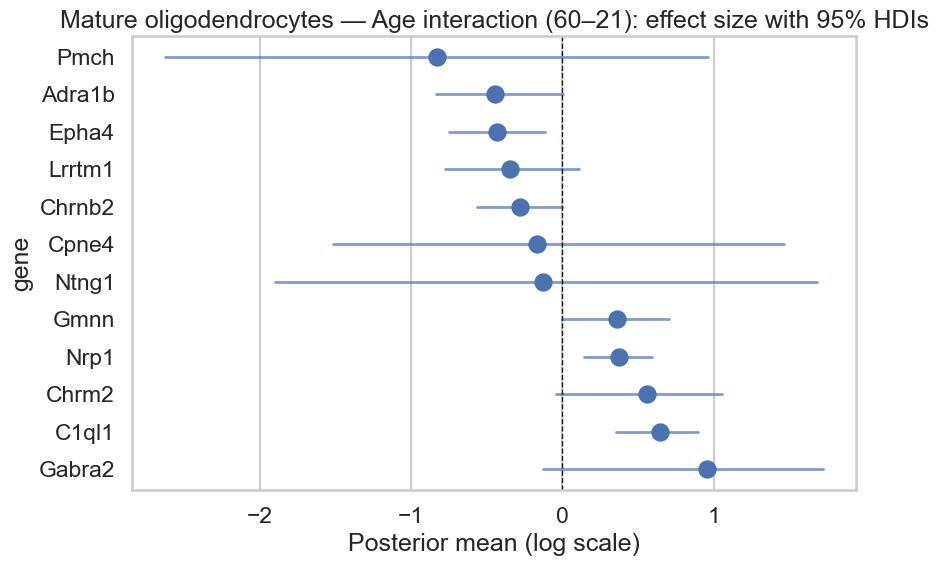

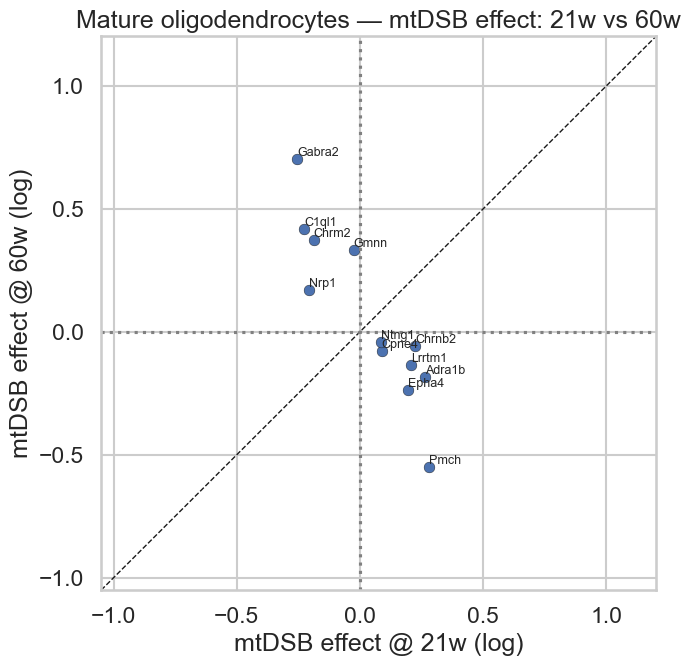

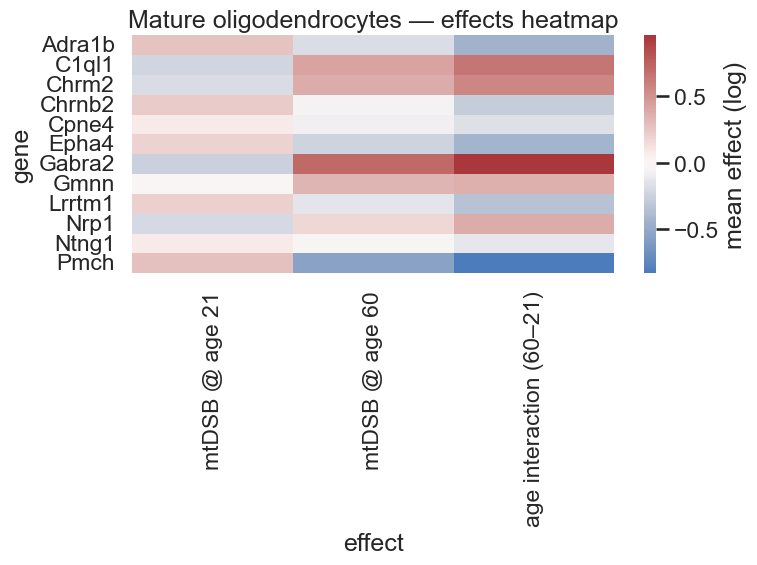

Plotting: Microglia


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_34401/763661744.py:17: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=keep, y="gene", x="mean", order=gene_order, join=False, color="C0")


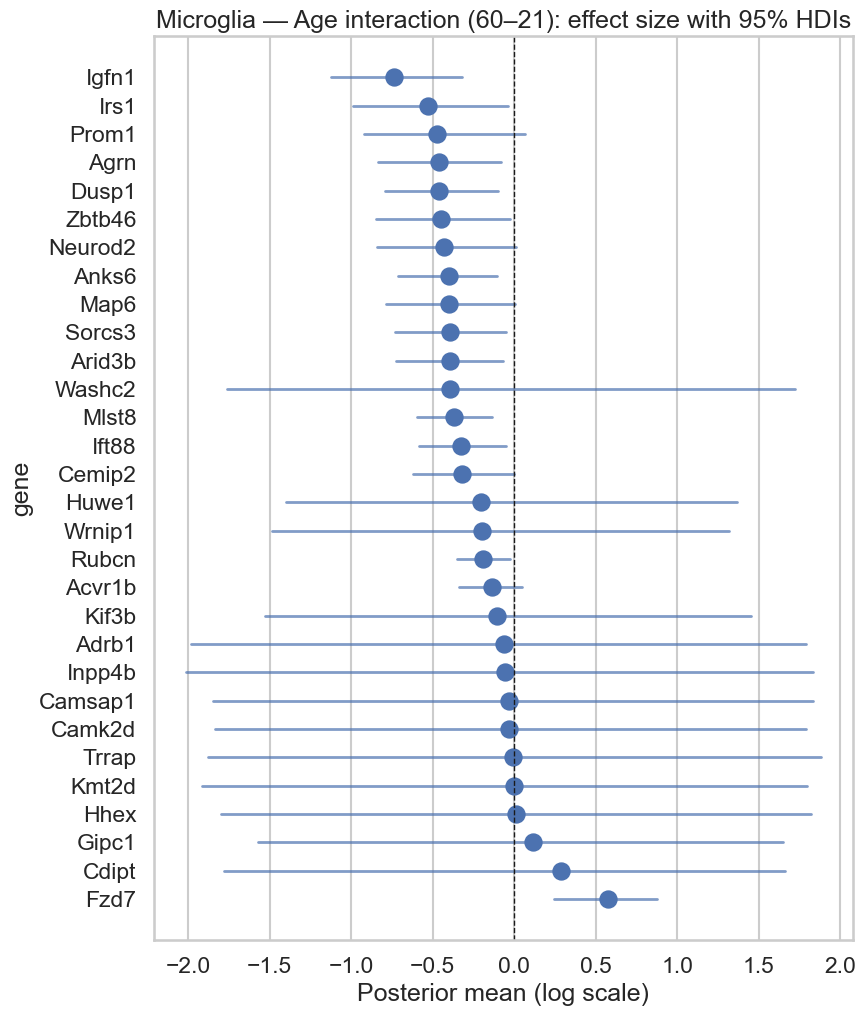

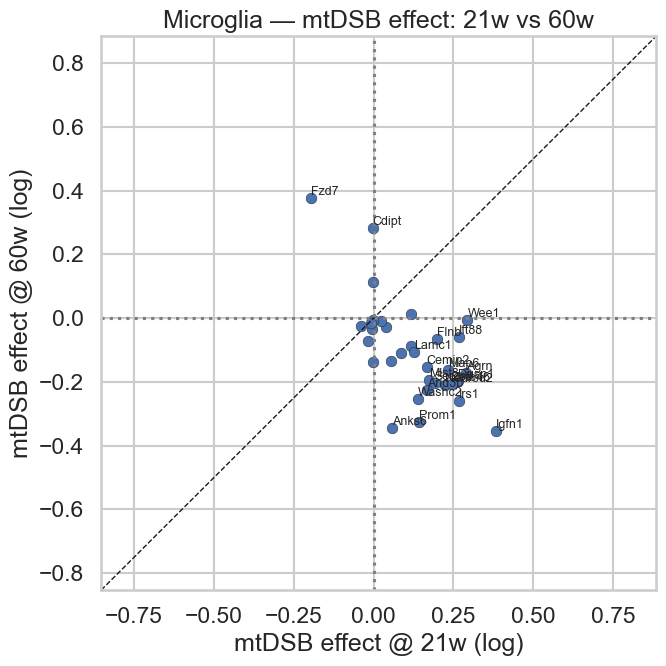

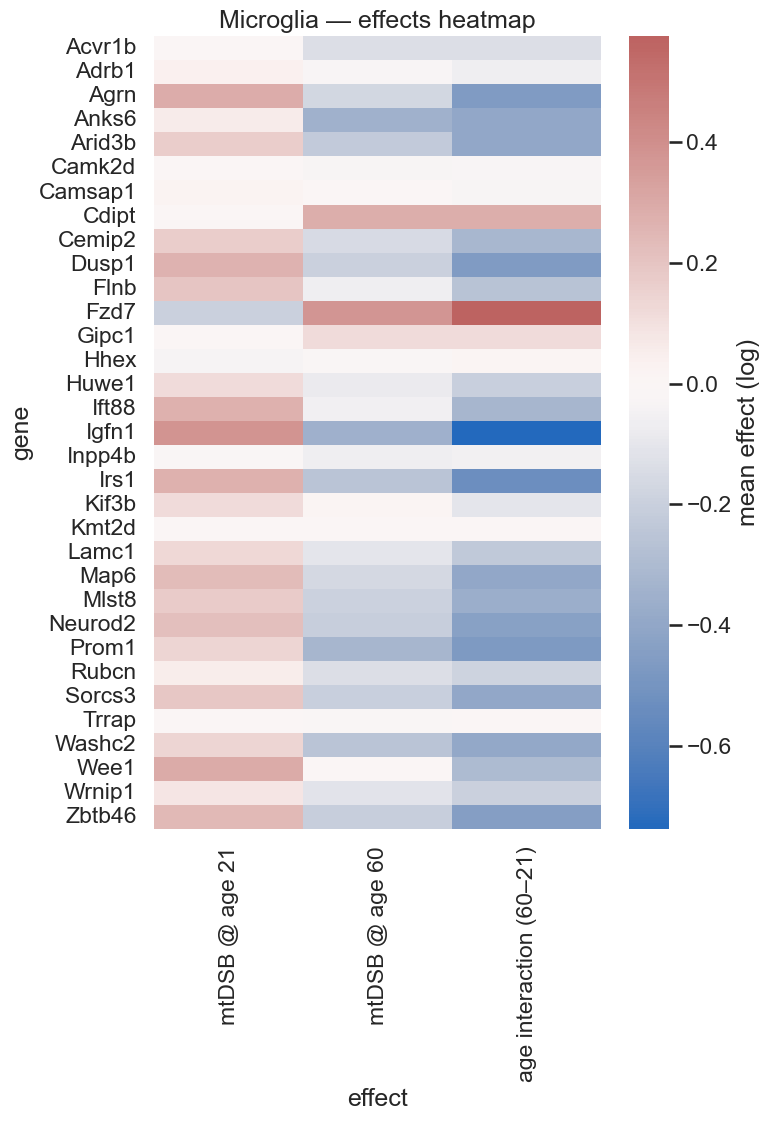

Plotting: Olfactory astrocytes


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_34401/763661744.py:17: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=keep, y="gene", x="mean", order=gene_order, join=False, color="C0")


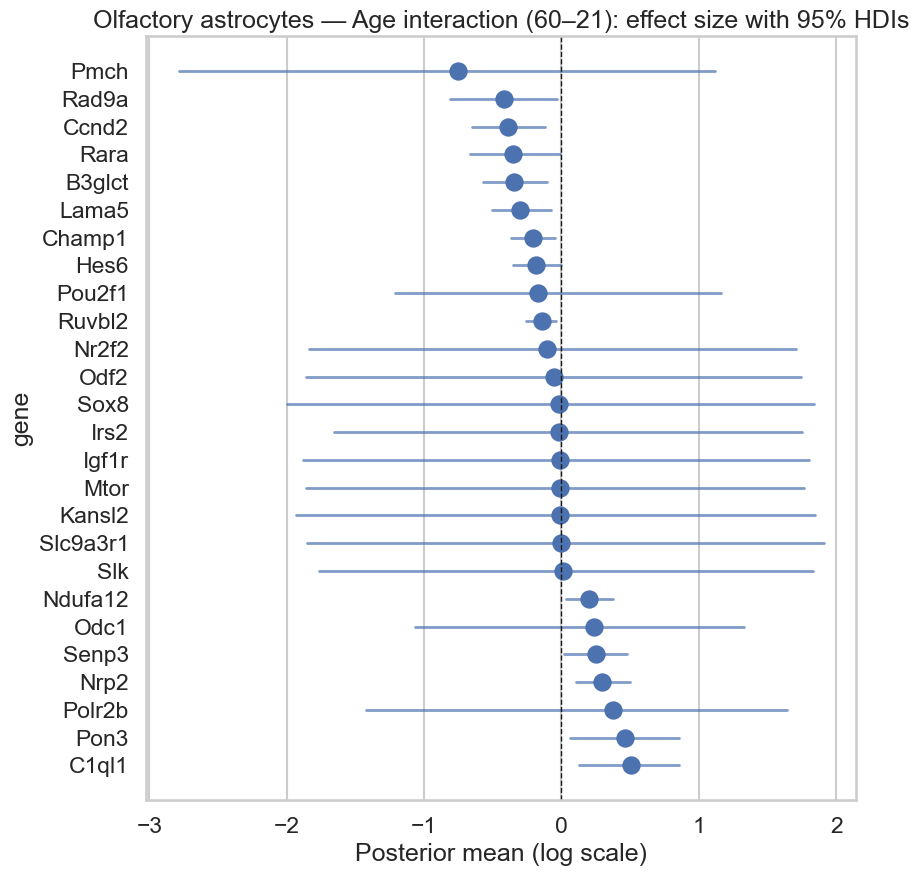

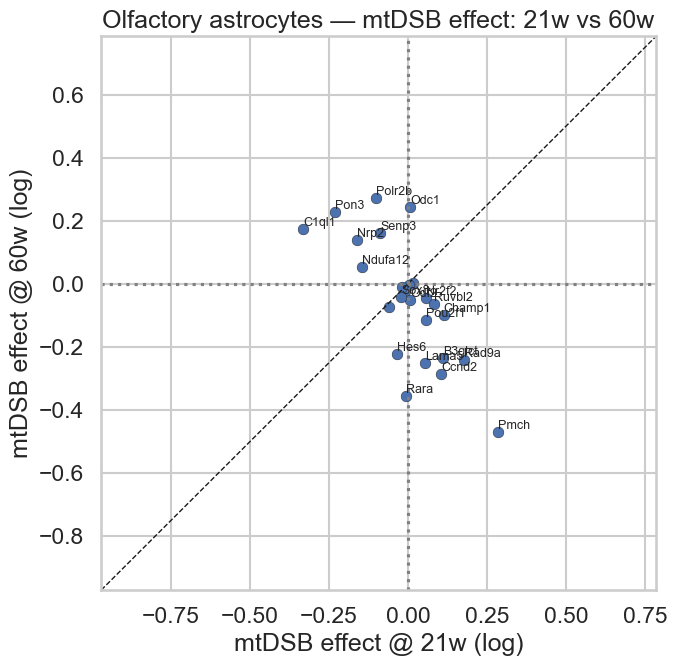

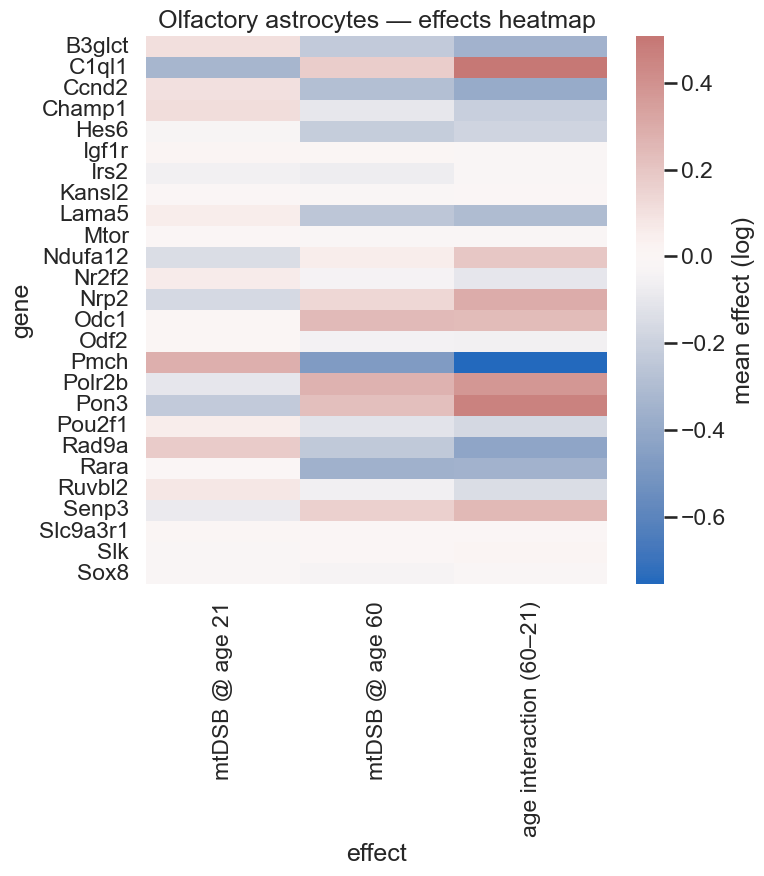

Plotting: Oligodendrocytes precursor cells


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_34401/763661744.py:17: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=keep, y="gene", x="mean", order=gene_order, join=False, color="C0")


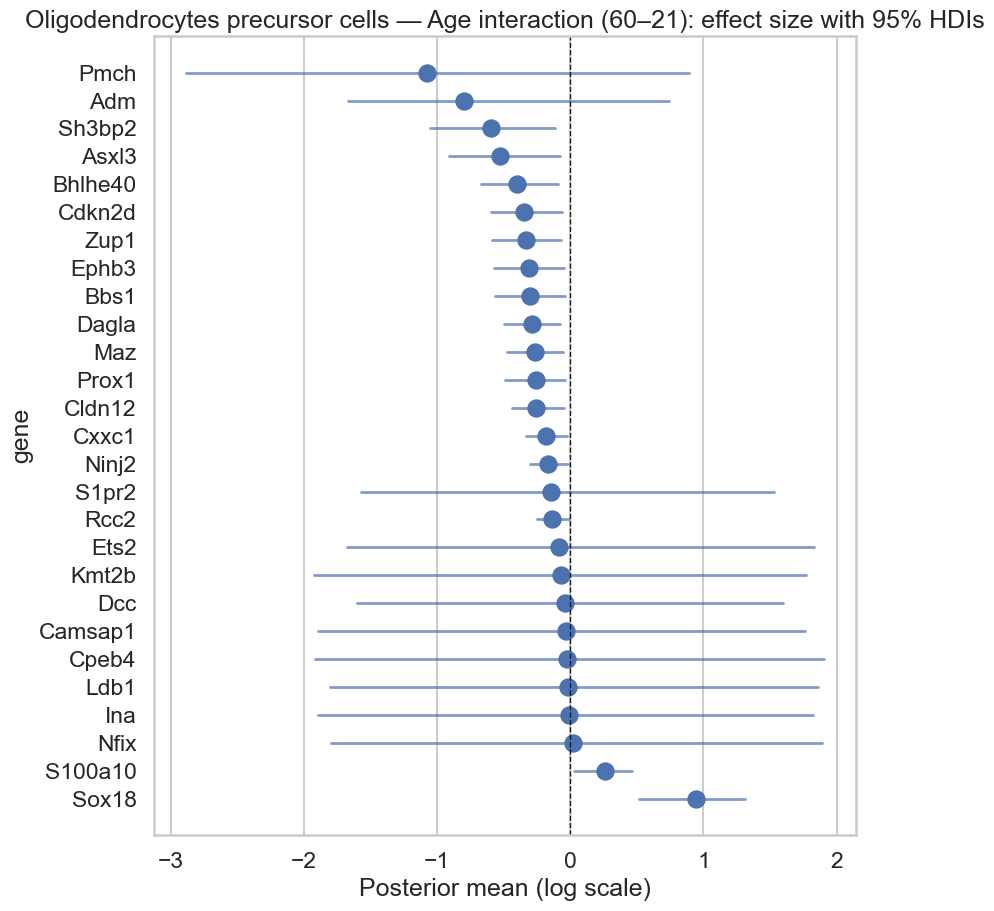

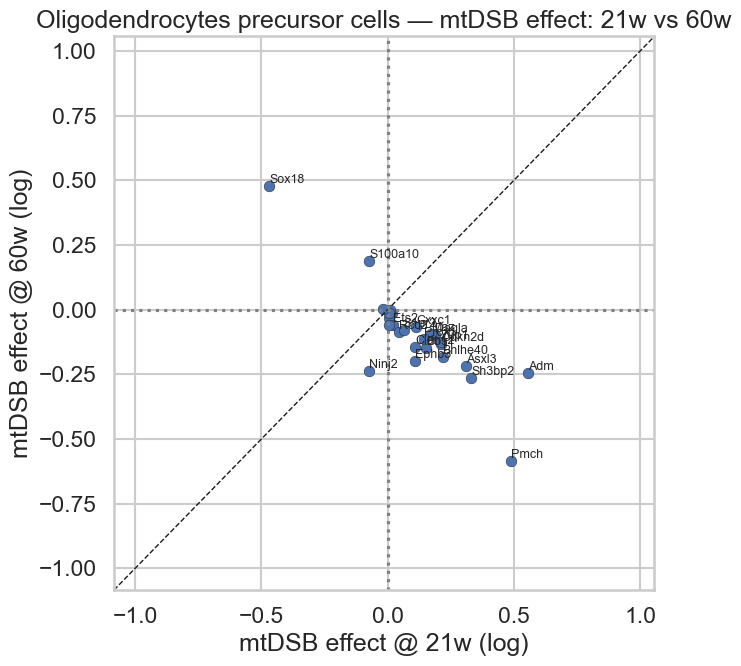

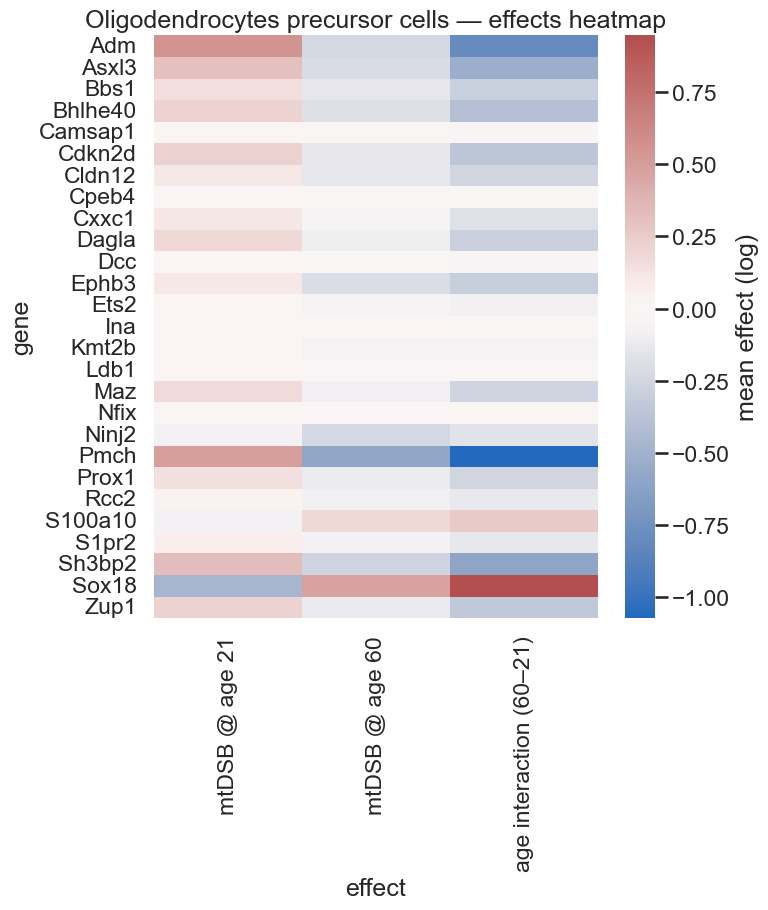

Plotting: Telencephalon astrocytes


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_34401/763661744.py:17: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(data=keep, y="gene", x="mean", order=gene_order, join=False, color="C0")


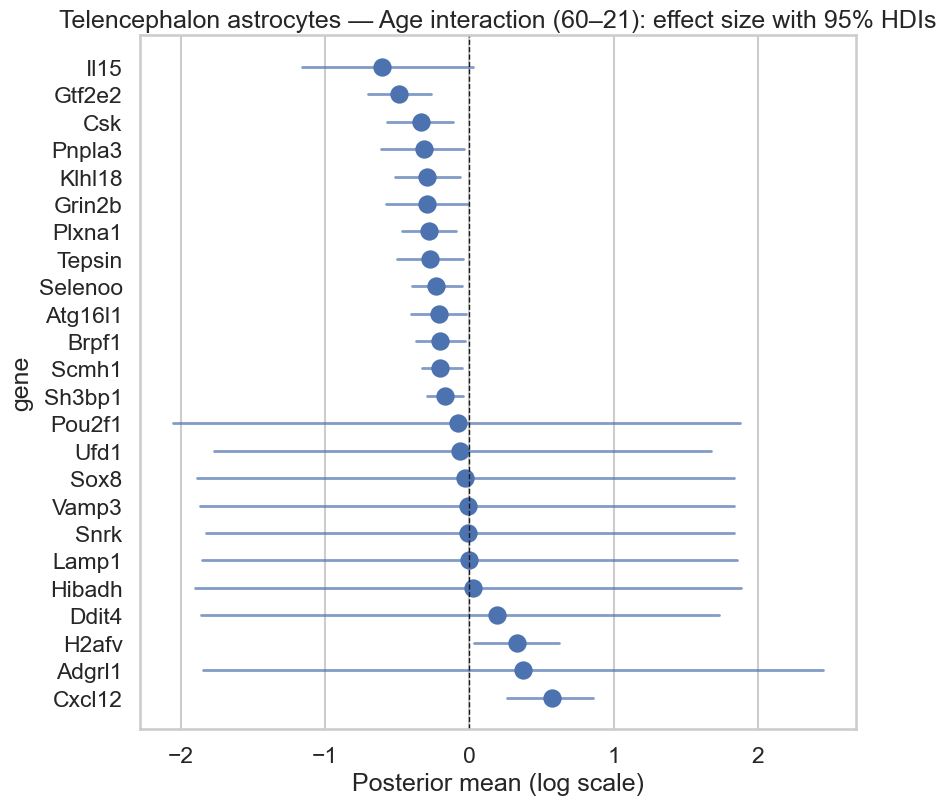

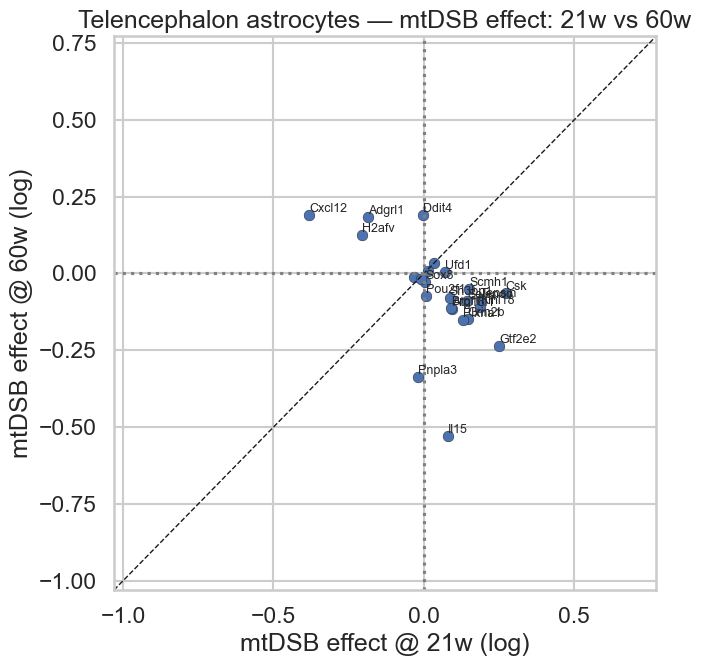

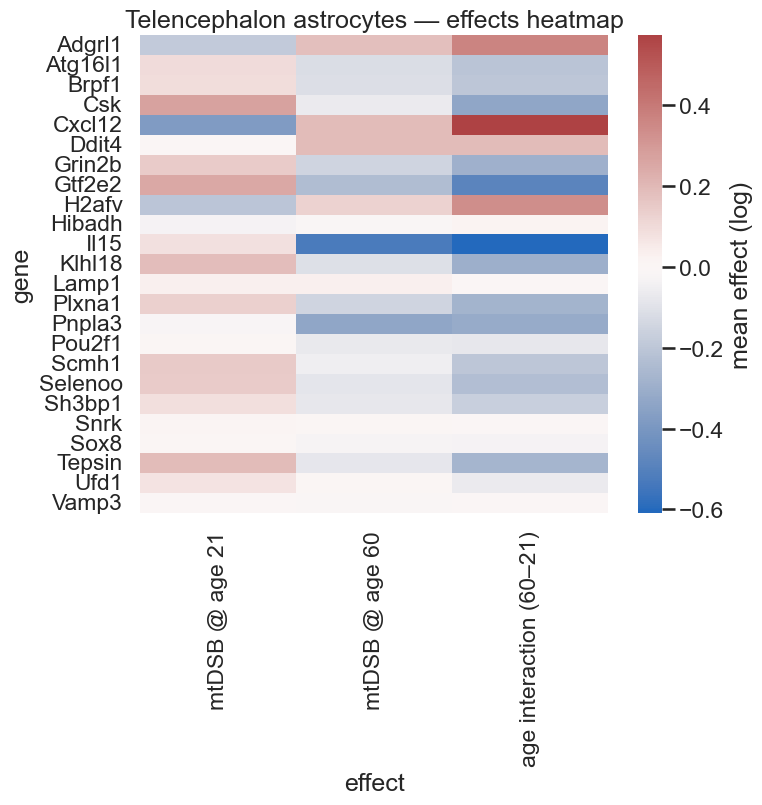

In [112]:
celltypes = summary_all["cell_class"].dropna().unique().tolist()
for ct in celltypes:
    print("Plotting:", ct)
    plot_interaction_caterpillar(summary_all, ct, top=30,
        save=f"../results/figures/{ct.replace(' ','_')}_interaction_caterpillar.png")
    plot_21_vs_60(summary_all, ct, label_top=20,
        save=f"../results/figures/{ct.replace(' ','_')}_21vs60_scatter.png")
    plot_effect_heatmap(summary_all, ct,
        save=f"../results/figures/{ct.replace(' ','_')}_effects_heatmap.png")

In [115]:
import pymc as pm
import numpy as np
import pandas as pd

def fit_gene_pymc_condition(df_gene,
                            advi=False,
                            draws=1000,
                            tune=1000,
                            chains=4,
                            target_accept=0.9,
                            seed=42):
    """
    Bayesian model for mtDSB vs control (condition only).
    """
    y = df_gene["value"].values
    cond = pd.Categorical(df_gene["condition"])
    cond_idx = cond.codes
    C = len(cond.categories)

    with pm.Model() as m:
        alpha = pm.Normal("alpha", 0, 1)
        sigma = pm.HalfNormal("sigma", 0.5)
        beta = pm.Normal("beta", 0, 1, shape=C)

        mu = alpha + beta[cond_idx]
        pm.Normal("obs", mu, sigma, observed=y)

        if advi:
            approx = pm.fit(20000, random_seed=seed)
            idata = approx.sample(draws)
        else:
            idata = pm.sample(
                draws=draws, tune=tune, chains=chains,
                target_accept=target_accept, random_seed=seed,
                return_inferencedata=True, progressbar=True
            )

    return idata, dict(categories=cond.categories.tolist())

In [116]:
import arviz as az

def summarize_condition_effect(idata, meta):
    post = az.summary(idata, var_names=["beta"], hdi_prob=0.95)
    post = post.reset_index().rename(columns={"index": "param"})
    post["condition"] = meta["categories"]
    return post

In [117]:
def fit_many_genes_condition(df_long, genes, celltypes,
                             *, advi=False, draws=1000, tune=1000, chains=4,
                             target_accept=0.9, seed=42):
    rows = []
    for ct in celltypes:
        df_ct = df_long[df_long["cell_class"] == ct]
        for g in genes:
            sub = df_ct[df_ct["gene"] == g]
            if sub.empty:
                continue
            idata, meta = fit_gene_pymc_condition(
                sub, advi=advi, draws=draws, tune=tune,
                chains=chains, target_accept=target_accept, seed=seed
            )
            eff = summarize_condition_effect(idata, meta)
            eff.insert(0, "gene", g)
            eff.insert(0, "cell_class", ct)
            rows.append(eff)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

In [118]:
# Example
celltypes_of_interest = ["Mature oligodendrocytes"]
genes_of_interest = sorted(df_filtered.loc[df_filtered["cell_class"].isin(celltypes_of_interest), "gene"].unique())

summary_condition = fit_many_genes_condition(
    df_filtered,
    genes=genes_of_interest,
    celltypes=celltypes_of_interest,
    advi=False,
    draws=1000,
    tune=1000,
    chains=4
)

summary_condition.to_csv("../results/bayes_condition_only.csv", index=False)
summary_condition.head()

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   0       0             0.00        0            0.00 draws/s     0:00:00   -:--:--    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   0       0             0.00        0            0.00 draws/s     0:00:00   -:--:--    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   0       0             0.00        0            0.00 draws/s     0:00:00   -:--:--    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   0       0             0.00        0            0.00 draws/s     0:00:00   -:--:--

ValueError: Not enough samples to build a trace.

In [ ]:
def plot_condition_caterpillar(df, cell_type, top=30):
    d = df[df["cell_class"]==cell_type].copy()
    if d.empty:
        print(f"No rows for {cell_type}")
        return

    d = d[d["condition"].str.contains("mtDSB", case=False)]
    d = d.sort_values("mean", ascending=False)
    keep = pd.concat([d.head(top//2), d.tail(top//2)]).drop_duplicates(subset="gene").sort_values("mean")

    plt.figure(figsize=(9, max(6, 0.35*len(keep))))
    sns.pointplot(data=keep, y="gene", x="mean", join=False, color="C0")
    for _, r in keep.iterrows():
        plt.plot([r["hdi_2.5%"], r["hdi_97.5%"]], [r["gene"], r["gene"]], color="C0", lw=2, alpha=.7)
    plt.axvline(0, ls="--", c="k", lw=1)
    plt.title(f"{cell_type} — mtDSB effect (condition-only model)")
    plt.xlabel("Posterior mean (log scale)"); plt.ylabel("gene")
    plt.tight_layout()
    plt.show()

In [ ]:
plot_condition_caterpillar(summary_condition, "Mature oligodendrocytes", top=40)